# Ablation comparison, VSN weights and attention

Reads the three ablation runs and produces the paper-ready answer to the reviewer comment:

> "Using MODFLOW predictions as a TFT input does not automatically ensure that the final predictions remain physically consistent. The TFT may assign limited importance to the MODFLOW variable or override its influence through correlations with observed groundwater-level lags. An ablation experiment should compare: TFT without MODFLOW input; TFT with MODFLOW input; the complete hybrid configuration. The manuscript should also present the Variable Selection Network weights and attention results."

What this notebook produces:

1. **Accuracy ladder** -- the three configurations scored on exactly the same test days, in feet, plus persistence as the reference; skill relative to the no-MODFLOW run answers "does the physics prior buy anything?"
2. **Diebold-Mariano tests** between every pair of configurations, so the ladder is reported with significance rather than as three bare numbers.
3. **VSN weights** -- Variable Selection Network importances per run, normalised to shares, with the MODFLOW share of encoder importance called out. This is what tells the reviewer whether the model *uses* the prior or leans on the observed water-level lags.
4. **Attention over lead time** -- how far back the model actually looks.
5. **Across seeds** -- if `05_multiseed_runs.ipynb` has run, the seed spread of both RMSE and the MODFLOW VSN share, which is the control on everything above.
6. **Exports** -- CSV and LaTeX tables plus two figures under `ablation_tests/results/tables/`.

**Run notebooks 01-03 first.** Missing runs are skipped with a message, so this notebook can be run while only some are finished. It needs no PyTorch: it only reads the CSV/JSON files those runs saved.

**Which folder each configuration is read from**: a configuration can exist both as a flat folder (written by 01-03) and as one folder per seed (written by 05). The seeded run selected by `PREFERRED_SEED` in section 1 wins when present, because the sweep saves the complete interpretation output including `attention_weights.csv`; the earliest hybrid run predates that file and cannot appear in the attention figure. Section 1 prints the folder chosen for each configuration, and names any other copy it found but did not use.


## 1. Configuration


In [32]:
import os
import json
import math

import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Same path handling as notebooks 01-03: work from the repo root.
REPO_ROOT_MARKERS = ('data', 'models')
if not all(os.path.isdir(m) for m in REPO_ROOT_MARKERS):
    if all(os.path.isdir(os.path.join('..', m)) for m in REPO_ROOT_MARKERS):
        os.chdir('..')
assert all(os.path.isdir(m) for m in REPO_ROOT_MARKERS), (
    f"Run from code_version_2/ or code_version_2/ablation_tests/; cwd is {os.getcwd()!r}"
)

PROCESSED_DIR = 'data/processed'
RESULTS_DIR = 'ablation_tests/results'
TABLES_DIR = os.path.join(RESULTS_DIR, 'tables')
os.makedirs(TABLES_DIR, exist_ok=True)

DATE_COL = 'date'
TARGET_COL = 'water_level'
EVAL_SPLIT = 'test'

# The ablation ladder, in the order it should appear in the paper.
# display name -> results subfolder written by notebooks 01/02/03
RUNS = {
    'TFT (no MODFLOW)':        'tft_no_modflow',
    'TFT + MODFLOW input':     'tft_modflow_input_only',
    'Complete hybrid':         'hybrid_full',
}
BASELINE_RUN = 'TFT (no MODFLOW)'   # reference for the "does physics help?" skill column

# Where each configuration's outputs are read from. A configuration can exist in
# two places: the flat folder written by 01-03, and one folder per seed written
# by 05_multiseed_runs.ipynb. The seeded run is preferred when present, because
# the sweep saves the complete interpretation output (variable_importance.csv
# AND attention_weights.csv), while the earliest hybrid run predates
# attention_weights.csv and so cannot appear in the attention figure.
# Set to None to ignore the sweep folders and use only the flat ones.
PREFERRED_SEED = 42


def resolve_run_dir(subdir):
    """First existing folder holding predictions for `subdir`, seeded first."""
    candidates = []
    if PREFERRED_SEED is not None:
        candidates.append(os.path.join(RESULTS_DIR, 'multiseed', f'seed_{PREFERRED_SEED}', subdir))
    candidates.append(os.path.join(RESULTS_DIR, subdir))

    found = [c for c in candidates if os.path.exists(os.path.join(c, 'hybrid_predictions.csv'))]
    return found[0] if found else candidates[-1], found[1:]


RUN_DIRS = {}
print('Run folders:')
for _name, _subdir in RUNS.items():
    _chosen, _others = resolve_run_dir(_subdir)
    RUN_DIRS[_name] = _chosen
    _exists = os.path.exists(os.path.join(_chosen, 'hybrid_predictions.csv'))
    print(f"  {_name:24s} -> {_chosen}" + ('' if _exists else '   (not run yet)'))
    for _other in _others:
        # Never let the choice be silent: two runs of the same configuration can
        # differ, so say which one is being scored.
        print(f"  {'':24s}    (also present, NOT used: {_other})")

# Colorblind-safe (Okabe-Ito) hues, assigned to runs in fixed order and reused
# in every figure so a configuration keeps its color throughout the paper.
RUN_COLORS = dict(zip(RUNS, ['#0072B2', '#E69F00', '#009E73']))
GRID_KW = dict(alpha=0.3, linewidth=0.6)

print('Working directory:', os.getcwd())
print('Reading runs from:', os.path.abspath(RESULTS_DIR))


Run folders:
  TFT (no MODFLOW)         -> ablation_tests/results\multiseed\seed_42\tft_no_modflow
                              (also present, NOT used: ablation_tests/results\tft_no_modflow)
  TFT + MODFLOW input      -> ablation_tests/results\tft_modflow_input_only
  Complete hybrid          -> ablation_tests/results\multiseed\seed_42\hybrid_full
                              (also present, NOT used: ablation_tests/results\hybrid_full)
Working directory: c:\Users\naima\Desktop\MODFLOW\Model\corrected_version\code_version_2
Reading runs from: c:\Users\naima\Desktop\MODFLOW\Model\corrected_version\code_version_2\ablation_tests\results


## 2. Observed series

Rebuilt exactly as the training pipeline builds it (`prepare_for_tft`): train, val and test concatenated, sorted by date, `time_idx = 0..N-1`. The assertion in section 3 confirms each run's saved `observed` column matches this series at the same `time_idx`, so the day alignment is verified rather than assumed.


In [33]:
frames = []
for split in ['train', 'val', 'test']:
    df = pd.read_csv(os.path.join(PROCESSED_DIR, f'{split}_scaled.csv'), parse_dates=[DATE_COL])
    df['split'] = split
    frames.append(df)

full_df = pd.concat(frames, ignore_index=True).sort_values(DATE_COL).reset_index(drop=True)
full_df['time_idx'] = np.arange(len(full_df))

target_scaler = joblib.load(os.path.join(PROCESSED_DIR, 'scalers.joblib'))['target_scaler']
full_df['y_scaled'] = full_df[TARGET_COL]
full_df['y_ft'] = target_scaler.inverse_transform(full_df[[TARGET_COL]]).ravel()
full_df['is_interpolated'] = full_df['is_interpolated'].astype(str).str.lower().eq('true')

assert (full_df[DATE_COL].diff().dt.days.dropna() == 1).all(), 'series must be continuous daily'

y = full_df.set_index('time_idx')['y_ft']
print(f'Scaler: mean={target_scaler.mean_[0]:.4f} ft, std={target_scaler.scale_[0]:.4f} ft')
print(full_df.groupby('split').agg(start=(DATE_COL, 'min'), end=(DATE_COL, 'max'), n=('y_ft', 'size')))


Scaler: mean=38.1640 ft, std=0.4517 ft
           start        end     n
split                            
test  2024-01-01 2025-12-12   712
train 2015-04-04 2021-12-31  2464
val   2022-01-01 2023-12-31   730


C:\Users\naima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 3. Load the ablation runs


In [34]:
runs = {}       # display name -> predictions in feet, indexed by time_idx
run_meta = {}   # display name -> run_config.json contents

for name, subdir in RUNS.items():
    folder = RUN_DIRS[name]
    pred_path = os.path.join(folder, 'hybrid_predictions.csv')
    if not os.path.exists(pred_path):
        print(f'  skipped (not run yet): {name} -> {pred_path}')
        continue

    pdf = pd.read_csv(pred_path).drop_duplicates('time_idx').set_index('time_idx').sort_index()

    # Alignment check: saved observations must match the reconstructed series
    ref = full_df.set_index('time_idx').loc[pdf.index, 'y_scaled']
    max_diff = np.nanmax(np.abs(pdf['observed'].to_numpy() - ref.to_numpy()))
    assert max_diff < 1e-6, f'{name}: observed values do not match time_idx alignment ({max_diff})'

    runs[name] = pd.Series(
        target_scaler.inverse_transform(pdf[['predicted']].to_numpy()).ravel(),
        index=pdf.index,
    )

    meta_path = os.path.join(folder, 'run_config.json')
    run_meta[name] = json.load(open(meta_path, encoding='utf-8')) if os.path.exists(meta_path) else {}
    mode = run_meta[name].get('modflow_feature_mode', '?')
    n_mf = run_meta[name].get('n_modflow_features', '?')
    print(f'  loaded: {name:24s} mode={mode:16s} MODFLOW inputs={n_mf}  days={len(pdf)}')

assert runs, 'No ablation runs found -- run notebooks 01-03 first.'

# Common evaluation days: in EVAL_SPLIT and predicted by every loaded run
common_idx = full_df.loc[full_df['split'] == EVAL_SPLIT, 'time_idx']
for s in runs.values():
    common_idx = common_idx[common_idx.isin(s.index)]
common_idx = common_idx.to_numpy()

eval_df = pd.DataFrame({
    'time_idx': common_idx,
    DATE_COL: full_df.set_index('time_idx').loc[common_idx, DATE_COL].to_numpy(),
    'observed_ft': y.reindex(common_idx).to_numpy(),
    'is_interpolated': full_df.set_index('time_idx').loc[common_idx, 'is_interpolated'].to_numpy(),
    'Persistence': y.reindex(common_idx - 1).to_numpy(),
})
for name, s in runs.items():
    eval_df[name] = s.reindex(common_idx).to_numpy()

MODEL_COLS = list(runs) + ['Persistence']
eval_df = eval_df[eval_df[['observed_ft'] + MODEL_COLS].notna().all(axis=1)].reset_index(drop=True)
print(f'\nCommon {EVAL_SPLIT} days: {len(eval_df)} '
      f'({eval_df[DATE_COL].min().date()} to {eval_df[DATE_COL].max().date()})')
eval_df.to_csv(os.path.join(TABLES_DIR, f'ablation_aligned_forecasts_{EVAL_SPLIT}.csv'), index=False)


  loaded: TFT (no MODFLOW)         mode=none             MODFLOW inputs=0  days=712
  loaded: TFT + MODFLOW input      mode=prediction_only  MODFLOW inputs=1  days=712
  loaded: Complete hybrid          mode=full             MODFLOW inputs=5  days=712

Common test days: 712 (2024-01-01 to 2025-12-12)


## 4. Accuracy ladder

All configurations are scored on identical days. Two skill columns matter for the reviewer's question:

- **Skill vs no-MODFLOW**: `1 - MSE_config / MSE_noMODFLOW`. Positive means the physics prior improved accuracy over the same architecture without it.
- **R² on daily change**: how much of the day-to-day movement the configuration explains. With a 1-day horizon the level R² is ~0.99 for everything, so it discriminates nothing; the daily change does.


In [36]:
def metric_row(obs, pred, prev, ref_mse, base_mse):
    err = pred - obs
    mse, mae = np.mean(err ** 2), np.mean(np.abs(err))
    d_obs, d_pred = obs - prev, pred - prev
    return {
        'n': len(obs),
        'RMSE (ft)': np.sqrt(mse),
        'MAE (ft)': mae,
        'Bias (ft)': np.mean(err),
        'NSE': 1 - np.sum(err ** 2) / np.sum((obs - obs.mean()) ** 2),
        'Skill vs persistence (%)': 100 * (1 - mse / ref_mse),
        'Skill vs no-MODFLOW (%)': 100 * (1 - mse / base_mse) if base_mse is not None else np.nan,
        'R2 on daily change': 1 - np.sum((d_obs - d_pred) ** 2) / np.sum((d_obs - d_obs.mean()) ** 2),
    }


def comparison_table(df):
    obs = df['observed_ft'].to_numpy()
    prev = y.reindex(df['time_idx'].to_numpy() - 1).to_numpy()
    ref_mse = np.mean((df['Persistence'].to_numpy() - obs) ** 2)
    base_mse = (np.mean((df[BASELINE_RUN].to_numpy() - obs) ** 2)
                if BASELINE_RUN in df.columns else None)
    rows = {m: metric_row(obs, df[m].to_numpy(), prev, ref_mse, base_mse) for m in MODEL_COLS}
    table = pd.DataFrame(rows).T
    table['n'] = table['n'].astype(int)
    # Keep the ladder in its configured order, persistence last
    return table.loc[[m for m in MODEL_COLS]]


measured = eval_df[~eval_df['is_interpolated']].reset_index(drop=True)
table_all = comparison_table(eval_df)
table_measured = comparison_table(measured)

pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print(f'=== {EVAL_SPLIT.upper()} split, all common days ===')
display(table_all) if 'display' in globals() else print(table_all.to_string())
print(f'\n=== {EVAL_SPLIT.upper()} split, measured days only (gap-filled days excluded) ===')
display(table_measured) if 'display' in globals() else print(table_measured.to_string())


=== TEST split, all common days ===
                       n  RMSE (ft)  MAE (ft)  Bias (ft)    NSE  Skill vs persistence (%)  Skill vs no-MODFLOW (%)  R2 on daily change
TFT (no MODFLOW)     712     0.0124    0.0094     0.0004 0.9932                   16.2040                   0.0000              0.1600
TFT + MODFLOW input  712     0.0122    0.0093     0.0019 0.9934                   18.7667                   3.0582              0.1857
Complete hybrid      712     0.0122    0.0092     0.0016 0.9934                   18.0024                   2.1461              0.1781
Persistence          712     0.0135    0.0096     0.0007 0.9919                    0.0000                 -19.3375             -0.0024

=== TEST split, measured days only (gap-filled days excluded) ===
                       n  RMSE (ft)  MAE (ft)  Bias (ft)    NSE  Skill vs persistence (%)  Skill vs no-MODFLOW (%)  R2 on daily change
TFT (no MODFLOW)     690     0.0124    0.0094     0.0004 0.9932                   16.81

## 5. Diebold-Mariano tests between configurations

Loss differential $d_t = L(e^A_t) - L(e^B_t)$ for squared and absolute error, with a Newey-West (HAC) long-run variance and the Harvey-Leybourne-Newbold small-sample correction -- the same implementation as `paper_comparison_dm_tests.ipynb`, so the two tables are directly comparable.

**Negative DM means A has lower loss than B.** Every ordered pair of loaded configurations is tested, plus each configuration against persistence.


In [37]:
def newey_west_lag(n):
    return int(np.floor(4 * (n / 100) ** (2 / 9)))


def diebold_mariano(e_a, e_b, loss='squared', h=1, hac_lag=None):
    d = e_a ** 2 - e_b ** 2 if loss == 'squared' else np.abs(e_a) - np.abs(e_b)
    n = len(d)
    lag = max(newey_west_lag(n) if hac_lag is None else hac_lag, h - 1)
    x = d - d.mean()
    lrv = np.mean(x * x)
    for k in range(1, lag + 1):
        lrv += 2 * (1 - k / (lag + 1)) * np.mean(x[k:] * x[:-k])
    if lrv <= 0:
        return dict(mean_loss_diff=d.mean(), DM=np.nan, DM_HLN=np.nan,
                    p_two_sided=np.nan, p_one_sided_A_better=np.nan, hac_lag=lag)
    dm = d.mean() / math.sqrt(lrv / n)
    dm_hln = dm * math.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    return dict(mean_loss_diff=d.mean(), DM=dm, DM_HLN=dm_hln,
                p_two_sided=2 * stats.t.sf(abs(dm_hln), df=n - 1),
                p_one_sided_A_better=stats.t.cdf(dm_hln, df=n - 1), hac_lag=lag)


def dm_table(df, subset_label):
    obs = df['observed_ft'].to_numpy()
    names = list(runs)
    rows = []
    pairs = [(a, b) for i, a in enumerate(names) for b in names[i + 1:]]
    pairs += [(a, 'Persistence') for a in names]
    for a, b in pairs:
        e_a, e_b = df[a].to_numpy() - obs, df[b].to_numpy() - obs
        for loss in ['squared', 'absolute']:
            rows.append({'subset': subset_label, 'model_A': a, 'model_B': b, 'loss': loss,
                         'n': len(obs), **diebold_mariano(e_a, e_b, loss=loss)})
    out = pd.DataFrame(rows)
    out['significant_5pct'] = out['p_two_sided'] < 0.05
    out['verdict'] = np.select(
        [out['significant_5pct'] & (out['DM_HLN'] < 0), out['significant_5pct'] & (out['DM_HLN'] > 0)],
        ['A significantly better', 'B significantly better'], 'no significant difference')
    return out


dm_results = pd.concat([dm_table(eval_df, 'all days'),
                        dm_table(measured, 'measured days only')], ignore_index=True)

pd.set_option('display.float_format', lambda v: f'{v:.4g}')
show_cols = ['subset', 'model_A', 'model_B', 'loss', 'n', 'DM_HLN', 'p_two_sided', 'verdict']
display(dm_results[show_cols]) if 'display' in globals() else print(dm_results[show_cols].to_string())


                subset              model_A              model_B      loss    n  DM_HLN  p_two_sided                    verdict
0             all days     TFT (no MODFLOW)  TFT + MODFLOW input   squared  712   1.528       0.1268  no significant difference
1             all days     TFT (no MODFLOW)  TFT + MODFLOW input  absolute  712  0.5855       0.5584  no significant difference
2             all days     TFT (no MODFLOW)      Complete hybrid   squared  712  0.9023       0.3672  no significant difference
3             all days     TFT (no MODFLOW)      Complete hybrid  absolute  712  0.9978       0.3187  no significant difference
4             all days  TFT + MODFLOW input      Complete hybrid   squared  712 -0.4568       0.6479  no significant difference
5             all days  TFT + MODFLOW input      Complete hybrid  absolute  712  0.6821       0.4954  no significant difference
6             all days     TFT (no MODFLOW)          Persistence   squared  712  -4.544    6.489e-06    

## 6. Variable Selection Network weights

Each run saved `interpretation/variable_importance.csv` (from `extract_and_save_interpretation`). Importances are normalised to **shares of encoder importance** within each run, so runs with different numbers of inputs can be compared.

The row that answers the reviewer directly is **MODFLOW share of encoder importance**: if the complete hybrid assigns the physics prior a negligible share while the water-level lags dominate, the prior is decorative and the manuscript must say so. Note this is a variable-selection weight, not a causal claim -- read it together with the accuracy ladder in section 4.


In [38]:
imp_frames = []
for name, subdir in RUNS.items():
    path = os.path.join(RUN_DIRS[name], 'interpretation', 'variable_importance.csv')
    if not os.path.exists(path):
        print(f'  skipped (no interpretation yet): {name} -> {path}')
        continue
    idf = pd.read_csv(path)
    idf['run'] = name
    imp_frames.append(idf)

if imp_frames:
    importance = pd.concat(imp_frames, ignore_index=True)
    enc = importance[importance['group'] == 'encoder'].copy()
    enc['share_pct'] = enc.groupby('run')['importance'].transform(lambda s: 100 * s / s.sum())

    vsn_wide = (enc.pivot_table(index='variable', columns='run', values='share_pct')
                   .reindex(columns=[n for n in RUNS if n in enc['run'].unique()]))

    def family(v):
        if v.startswith('modflow'):
            return 'MODFLOW (physics prior)'
        if v.startswith('water_level'):
            return 'Observed water-level history'
        if v in ('month_sin', 'month_cos', 'doy_sin', 'doy_cos'):
            return 'Calendar'
        if v in ('relative_time_idx', 'encoder_length', 'center', 'scale'):
            return 'Dataset bookkeeping'
        return 'Climate forcing'

    enc['family'] = enc['variable'].map(family)
    family_wide = (enc.pivot_table(index='family', columns='run', values='share_pct', aggfunc='sum')
                      .reindex(columns=[n for n in RUNS if n in enc['run'].unique()])
                      .fillna(0.0))

    print('=== Encoder variable importance, share of run total (%) ===')
    display(vsn_wide.round(2)) if 'display' in globals() else print(vsn_wide.round(2).to_string())
    print('\n=== Grouped by variable family (%) ===')
    display(family_wide.round(2)) if 'display' in globals() else print(family_wide.round(2).to_string())
    print('\nMODFLOW share of encoder importance:')
    for run in family_wide.columns:
        print(f"  {run:24s} {family_wide.loc['MODFLOW (physics prior)', run]:6.2f} %"
              if 'MODFLOW (physics prior)' in family_wide.index else f'  {run}: 0 %')
else:
    importance = enc = vsn_wide = family_wide = None
    print('No interpretation files found; run notebooks 01-03 first.')


=== Encoder variable importance, share of run total (%) ===
run                       TFT (no MODFLOW)  TFT + MODFLOW input  Complete hybrid
variable                                                                        
2m_temperature_mean                   3.81                 1.16             5.04
doy_cos                               5.41                  8.7              2.7
doy_sin                               7.27                 4.33             4.45
evaporation_sum                      10.53                 1.86             1.78
modflow_lag_1                          NaN                  NaN              1.8
modflow_lag_7                          NaN                  NaN             1.34
modflow_residual_lag_1                 NaN                  NaN             5.27
modflow_rmean_7                        NaN                  NaN             0.45
modflow_scaled                         NaN                 0.81             6.01
month_cos                             13.8       

## 7. Figure: variable-importance shares by family


Saved: ablation_tests/results\tables\vsn_importance_by_family.png


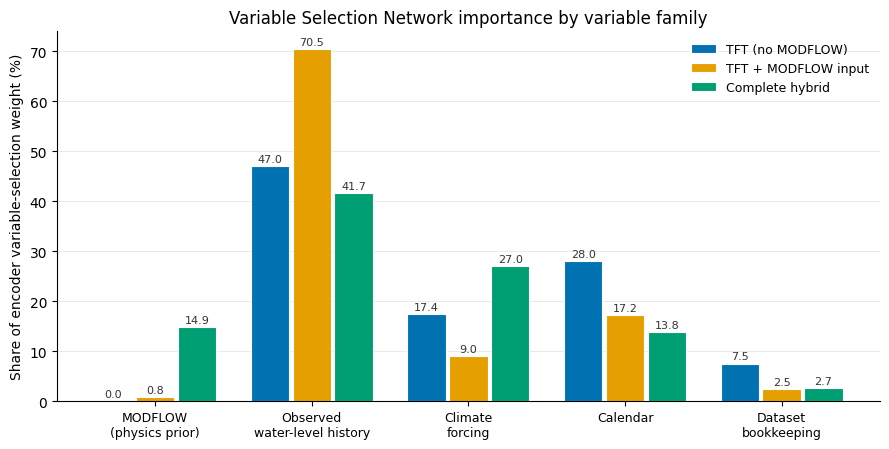

In [39]:
if family_wide is not None and not family_wide.empty:
    order = [f for f in ['MODFLOW (physics prior)', 'Observed water-level history',
                         'Climate forcing', 'Calendar', 'Dataset bookkeeping']
             if f in family_wide.index]
    plot_df = family_wide.loc[order]
    x = np.arange(len(order))
    n_runs = len(plot_df.columns)
    width = 0.8 / n_runs

    fig, ax = plt.subplots(figsize=(9, 4.6))
    for i, run in enumerate(plot_df.columns):
        pos = x - 0.4 + width * (i + 0.5)
        vals = plot_df[run].to_numpy()
        ax.bar(pos, vals, width * 0.92, label=run, color=RUN_COLORS[run],
               edgecolor='white', linewidth=0.8)
        # Direct value labels: the reviewer needs the MODFLOW share readable,
        # not estimated off the axis.
        for px, v in zip(pos, vals):
            ax.annotate(f'{v:.1f}', (px, v), textcoords='offset points', xytext=(0, 3),
                        ha='center', fontsize=8, color='#333333')

    FAMILY_LABELS = {
        'MODFLOW (physics prior)': 'MODFLOW\n(physics prior)',
        'Observed water-level history': 'Observed\nwater-level history',
        'Climate forcing': 'Climate\nforcing',
        'Calendar': 'Calendar',
        'Dataset bookkeeping': 'Dataset\nbookkeeping',
    }
    ax.set_xticks(x)
    ax.set_xticklabels([FAMILY_LABELS.get(o, o) for o in order], fontsize=9)
    ax.set_ylabel('Share of encoder variable-selection weight (%)')
    ax.set_title('Variable Selection Network importance by variable family')
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', **GRID_KW)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    path = os.path.join(TABLES_DIR, 'vsn_importance_by_family.png')
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()


## 8. Figure: attention over lead time

From each run's `interpretation/attention_weights.csv`. **Check the orientation once** against the `interpretation_attention.png` saved next to it: pytorch_forecasting returns attention from the oldest encoder step to the forecast step, and `days_before_forecast` is derived on that assumption. If the plot looks reversed, flip the column rather than the figure.


Saved: ablation_tests/results\tables\attention_over_lead_time.png


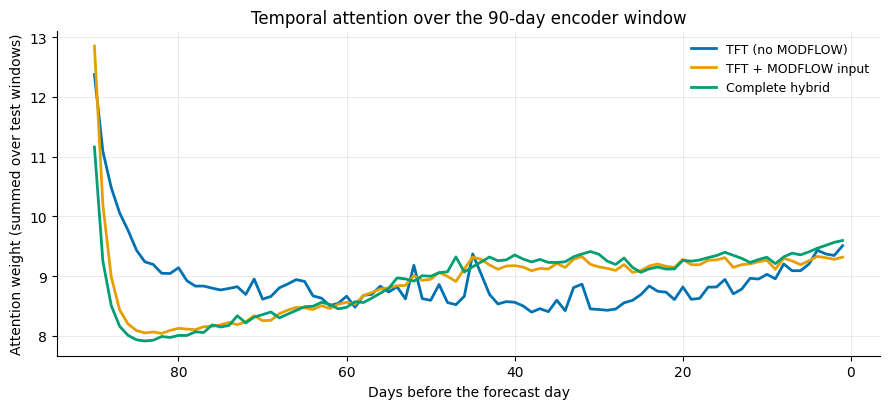

In [40]:
attn = {}
for name, subdir in RUNS.items():
    path = os.path.join(RUN_DIRS[name], 'interpretation', 'attention_weights.csv')
    if os.path.exists(path):
        attn[name] = pd.read_csv(path)
    else:
        print(f'  skipped (no attention file yet): {name}')

if attn:
    fig, ax = plt.subplots(figsize=(9, 4.2))
    for name, adf in attn.items():
        ax.plot(adf['days_before_forecast'], adf['attention'], linewidth=2,
                color=RUN_COLORS[name], label=name)
    ax.invert_xaxis()   # most recent day nearest the forecast on the right
    ax.set_xlabel('Days before the forecast day')
    ax.set_ylabel('Attention weight (summed over test windows)')
    ax.set_title('Temporal attention over the 90-day encoder window')
    ax.legend(frameon=False, fontsize=9)
    ax.grid(**GRID_KW)
    ax.set_axisbelow(True)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    path = os.path.join(TABLES_DIR, 'attention_over_lead_time.png')
    fig.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()


## 9. Across seeds — is the MODFLOW gap bigger than run-to-run variation?

Sections 4-8 score **one run per configuration**. This section reads every seed folder
written by `05_multiseed_runs.ipynb` (`results/multiseed/seed_*/`) and reports, per
configuration, the spread of test RMSE and of the MODFLOW share of VSN weight.

It is the control on everything above. Retraining the same configuration with a different
seed changes the result by some amount; if that amount is comparable to the gap between
configurations, then the gap is not evidence about the physics prior. The cell skips itself
when the sweep has not been run.


In [41]:
seed_rows = []
for cfg_path in sorted(glob.glob(os.path.join(RESULTS_DIR, 'multiseed', 'seed_*', '*', 'run_config.json'))):
    run_folder = os.path.dirname(cfg_path)
    subdir = os.path.basename(run_folder)
    seed = os.path.basename(os.path.dirname(run_folder)).replace('seed_', '')
    display_name = next((n for n, s in RUNS.items() if s == subdir), subdir)

    with open(cfg_path, encoding='utf-8') as fh:
        cfg = json.load(fh)
    test_metrics = cfg.get('test_metrics', {})
    val_metrics = cfg.get('val_metrics', {})

    # MODFLOW share of encoder variable-selection weight, same definition as section 6
    modflow_share = np.nan
    imp_path = os.path.join(run_folder, 'interpretation', 'variable_importance.csv')
    if os.path.exists(imp_path):
        idf = pd.read_csv(imp_path)
        idf = idf[idf['group'] == 'encoder']
        if idf['importance'].sum() > 0:
            modflow_share = 100 * idf.loc[idf['variable'].str.startswith('modflow'),
                                          'importance'].sum() / idf['importance'].sum()

    seed_rows.append({
        'configuration': display_name,
        'seed': int(seed) if seed.isdigit() else seed,
        'epochs': cfg.get('epochs_run'),
        'test_RMSE_ft': test_metrics.get('RMSE', np.nan) * target_scaler.scale_[0],
        'test_R2': test_metrics.get('R2', np.nan),
        'val_RMSE_ft': val_metrics.get('RMSE', np.nan) * target_scaler.scale_[0],
        'MODFLOW_VSN_share_pct': modflow_share,
    })

if not seed_rows:
    seed_summary = None
    print('No multi-seed runs found under '
          f"{os.path.join(RESULTS_DIR, 'multiseed')} -- run 05_multiseed_runs.ipynb first.")
else:
    seed_df = pd.DataFrame(seed_rows).sort_values(['configuration', 'seed'])
    print('=== Per seed ===')
    display(seed_df) if 'display' in globals() else print(seed_df.to_string(index=False))

    seed_summary = seed_df.groupby('configuration').agg(
        n_seeds=('seed', 'size'),
        mean_test_RMSE_ft=('test_RMSE_ft', 'mean'),
        std_test_RMSE_ft=('test_RMSE_ft', 'std'),
        min_test_RMSE_ft=('test_RMSE_ft', 'min'),
        max_test_RMSE_ft=('test_RMSE_ft', 'max'),
        mean_val_RMSE_ft=('val_RMSE_ft', 'mean'),
        mean_MODFLOW_VSN_pct=('MODFLOW_VSN_share_pct', 'mean'),
        min_MODFLOW_VSN_pct=('MODFLOW_VSN_share_pct', 'min'),
        max_MODFLOW_VSN_pct=('MODFLOW_VSN_share_pct', 'max'),
    )
    seed_summary['seed_spread_ft'] = (seed_summary['max_test_RMSE_ft']
                                      - seed_summary['min_test_RMSE_ft'])
    print('\n=== Per configuration, across seeds ===')
    display(seed_summary) if 'display' in globals() else print(seed_summary.to_string())

    seed_df.to_csv(os.path.join(TABLES_DIR, 'multiseed_per_run.csv'), index=False)
    seed_summary.to_csv(os.path.join(TABLES_DIR, 'multiseed_summary.csv'))
    print(f"\nSaved: {os.path.join(TABLES_DIR, 'multiseed_per_run.csv')}")
    print(f"Saved: {os.path.join(TABLES_DIR, 'multiseed_summary.csv')}")

    # The verdict, in the terms the response letter needs
    if {BASELINE_RUN, 'Complete hybrid'} <= set(seed_summary.index):
        effect = (seed_summary.loc[BASELINE_RUN, 'mean_test_RMSE_ft']
                  - seed_summary.loc['Complete hybrid', 'mean_test_RMSE_ft'])
        spread = float(seed_summary['seed_spread_ft'].max())
        n_min = int(seed_summary.loc[[BASELINE_RUN, 'Complete hybrid'], 'n_seeds'].min())
        print(f"\nMean RMSE difference (no-MODFLOW - complete hybrid): {effect:+.6f} ft")
        print(f"Largest within-configuration seed spread:              {spread:.6f} ft")
        if n_min < 3:
            print(f"\n=> Only {n_min} seed(s) per configuration so far; the spread is not yet "
                  "a meaningful estimate. Let the sweep finish before quoting this.")
        elif effect <= spread:
            print("\n=> The MODFLOW effect is NOT larger than seed-to-seed variation. "
                  "Report the physics prior as not measurably improving one-day-ahead "
                  "accuracy, and cite these numbers as the evidence.")
        else:
            print("\n=> The MODFLOW effect EXCEEDS seed-to-seed variation. It survives "
                  "retraining; report it as mean and spread over seeds, never as a "
                  "single run.")


=== Per seed ===
   configuration  seed  epochs  test_RMSE_ft  test_R2  val_RMSE_ft  MODFLOW_VSN_share_pct
 Complete hybrid     1     186       0.01245   0.9931      0.01481                   29.5
 Complete hybrid     2     225       0.01277   0.9928      0.01495                  16.58
 Complete hybrid    42     214       0.01225   0.9934      0.01486                  14.87
TFT (no MODFLOW)     1     187       0.01238   0.9932      0.01453                      0
TFT (no MODFLOW)     2     218       0.01224   0.9934      0.01458                      0
TFT (no MODFLOW)     3     209       0.01221   0.9934      0.01449                    NaN
TFT (no MODFLOW)    42     217       0.01238   0.9932       0.0147                      0

=== Per configuration, across seeds ===
                  n_seeds  mean_test_RMSE_ft  std_test_RMSE_ft  min_test_RMSE_ft  max_test_RMSE_ft  mean_val_RMSE_ft  mean_MODFLOW_VSN_pct  min_MODFLOW_VSN_pct  max_MODFLOW_VSN_pct  seed_spread_ft
configuration            

## 10. Export tables (CSV and LaTeX)


In [42]:
def to_latex_simple(df, caption, label, float_fmt='{:.4f}', index_name='Configuration'):
    cols = list(df.columns)
    esc = lambda s: str(s).replace('%', r'\%').replace('_', r'\_').replace('&', r'\&')
    lines = [r'\begin{table}[htbp]', r'\centering', rf'\caption{{{caption}}}', rf'\label{{{label}}}',
             r'\begin{tabular}{l' + 'r' * len(cols) + '}', r'\hline',
             ' & '.join([index_name] + [esc(c) for c in cols]) + r' \\', r'\hline']
    for idx, row in df.iterrows():
        cells_out = []
        for c in cols:
            v = row[c]
            if isinstance(v, (int, np.integer)):
                cells_out.append(str(v))
            elif isinstance(v, (float, np.floating)):
                cells_out.append('--' if np.isnan(v) else float_fmt.format(v))
            else:
                cells_out.append(esc(v))
        lines.append(' & '.join([esc(idx)] + cells_out) + r' \\')
    lines += [r'\hline', r'\end{tabular}', r'\end{table}']
    return '\n'.join(lines)


def write_pair(df, stem, caption, label, index_name='Configuration', float_fmt='{:.4f}'):
    csv_path = os.path.join(TABLES_DIR, f'{stem}.csv')
    tex_path = os.path.join(TABLES_DIR, f'{stem}.tex')
    df.to_csv(csv_path, index_label=index_name.lower())
    with open(tex_path, 'w', encoding='utf-8') as fh:
        fh.write(to_latex_simple(df, caption, label, float_fmt=float_fmt, index_name=index_name))
    print(f'Saved: {csv_path}\nSaved: {tex_path}')


paper_cols = ['n', 'RMSE (ft)', 'MAE (ft)', 'Bias (ft)', 'NSE',
              'Skill vs persistence (%)', 'Skill vs no-MODFLOW (%)', 'R2 on daily change']

write_pair(table_all[paper_cols], f'ablation_table_{EVAL_SPLIT}_all_days',
           caption=('MODFLOW ablation ladder: one-day-ahead accuracy on the '
                    f'{EVAL_SPLIT} period (all common days). All configurations share '
                    'architecture, hyperparameters, splits and seed; only the MODFLOW '
                    'feature set differs.'),
           label=f'tab:ablation_{EVAL_SPLIT}')
write_pair(table_measured[paper_cols], f'ablation_table_{EVAL_SPLIT}_measured_days',
           caption=('MODFLOW ablation ladder on measured days only (gap-filled USGS '
                    'days excluded).'),
           label=f'tab:ablation_{EVAL_SPLIT}_measured')

# Full per-subset results (both loss functions, both subsets, DM/HLN/p/HAC lag).
# Kept under its own name: the paper-formatted pivot below writes
# ablation_dm_tests_<split>.csv and would otherwise overwrite this.
dm_results.to_csv(os.path.join(TABLES_DIR, f'ablation_dm_tests_{EVAL_SPLIT}_full.csv'), index=False)
dm_paper = dm_results[dm_results['subset'] == 'all days'].pivot_table(
    index=['model_A', 'model_B'], columns='loss', values=['DM_HLN', 'p_two_sided'], aggfunc='first')
dm_paper.columns = [f'{stat} ({loss})' for stat, loss in dm_paper.columns]
dm_paper = dm_paper[['DM_HLN (squared)', 'p_two_sided (squared)',
                     'DM_HLN (absolute)', 'p_two_sided (absolute)']]
dm_fmt = dm_paper.copy()
for c in dm_fmt.columns:
    dm_fmt[c] = [('<0.001' if v < 0.001 else f'{v:.3f}') if c.startswith('p_') else f'{v:.2f}'
                 for v in dm_fmt[c]]
dm_fmt.index = [f'{a} vs {b}' for a, b in dm_fmt.index]
dm_fmt.columns = ['DM (SE)', 'p (SE)', 'DM (AE)', 'p (AE)']
write_pair(dm_fmt, f'ablation_dm_tests_{EVAL_SPLIT}',
           caption=(f'Diebold--Mariano tests between ablation configurations ({EVAL_SPLIT} '
                    'period, h = 1, Newey--West HAC variance with Harvey--Leybourne--Newbold '
                    'correction). Negative DM: the first model is more accurate. '
                    'SE = squared error, AE = absolute error.'),
           label=f'tab:ablation_dm_{EVAL_SPLIT}', index_name='Comparison')

if vsn_wide is not None:
    write_pair(vsn_wide.round(2), 'vsn_importance_by_variable',
               caption=('Variable Selection Network importance per input, as a share (\\%) of '
                        'each run total encoder importance.'),
               label='tab:vsn_variables', index_name='Variable', float_fmt='{:.2f}')
    write_pair(family_wide.round(2), 'vsn_importance_by_family',
               caption=('Variable Selection Network importance grouped by variable family, as a '
                        'share (\\%) of each run total encoder importance.'),
               label='tab:vsn_families', index_name='Variable family', float_fmt='{:.2f}')


Saved: ablation_tests/results\tables\ablation_table_test_all_days.csv
Saved: ablation_tests/results\tables\ablation_table_test_all_days.tex
Saved: ablation_tests/results\tables\ablation_table_test_measured_days.csv
Saved: ablation_tests/results\tables\ablation_table_test_measured_days.tex
Saved: ablation_tests/results\tables\ablation_dm_tests_test.csv
Saved: ablation_tests/results\tables\ablation_dm_tests_test.tex
Saved: ablation_tests/results\tables\vsn_importance_by_variable.csv
Saved: ablation_tests/results\tables\vsn_importance_by_variable.tex
Saved: ablation_tests/results\tables\vsn_importance_by_family.csv
Saved: ablation_tests/results\tables\vsn_importance_by_family.tex


## 11. Summary sentences for the response letter

Generated from the numbers above so the letter and the tables cannot drift apart. Read the wording before pasting it: it reports whatever the runs actually show, including the case where the physics prior does **not** help.


In [43]:
def p_text(p):
    return 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'


print('ABLATION LADDER\n' + '-' * 70)
for name in runs:
    r = table_all.loc[name]
    print(f"{name}: RMSE = {r['RMSE (ft)']:.4f} ft, R2 on the daily change = "
          f"{r['R2 on daily change']:.3f}, skill against persistence = "
          f"{r['Skill vs persistence (%)']:+.1f} %"
          + ('' if name == BASELINE_RUN or np.isnan(r['Skill vs no-MODFLOW (%)'])
             else f", skill against the no-MODFLOW configuration = {r['Skill vs no-MODFLOW (%)']:+.1f} %")
          + '.')

if BASELINE_RUN in runs and 'Complete hybrid' in runs:
    row = dm_results.query("subset == 'all days' and loss == 'squared' and "
                           "((model_A == @BASELINE_RUN and model_B == 'Complete hybrid') or "
                           " (model_A == 'Complete hybrid' and model_B == @BASELINE_RUN))")
    if len(row):
        row = row.iloc[0]
        better = row['model_A'] if row['DM_HLN'] < 0 else row['model_B']
        print(f"\nDiebold-Mariano, complete hybrid against the no-MODFLOW configuration "
              f"(squared-error loss): DM = {row['DM_HLN']:.2f}, {p_text(row['p_two_sided'])} -- "
              + (f"{better} is significantly more accurate."
                 if row['p_two_sided'] < 0.05 else
                 "the two configurations are not significantly different in accuracy."))

if family_wide is not None and 'MODFLOW (physics prior)' in family_wide.index:
    print('\nVARIABLE SELECTION NETWORK\n' + '-' * 70)
    for run in family_wide.columns:
        mf = family_wide.loc['MODFLOW (physics prior)', run]
        gw = family_wide.loc['Observed water-level history', run] \
            if 'Observed water-level history' in family_wide.index else float('nan')
        print(f'{run}: MODFLOW-derived inputs take {mf:.1f} % of the encoder '
              f'variable-selection weight, against {gw:.1f} % for the observed '
              f'water-level history.')
    print('\nInterpret this together with the accuracy ladder: a small MODFLOW share '
          'combined with no accuracy gain means the prior is not contributing, and the '
          'manuscript should state that rather than claim physical consistency.')


ABLATION LADDER
----------------------------------------------------------------------
TFT (no MODFLOW): RMSE = 0.0124 ft, R2 on the daily change = 0.160, skill against persistence = +16.2 %.
TFT + MODFLOW input: RMSE = 0.0122 ft, R2 on the daily change = 0.186, skill against persistence = +18.8 %, skill against the no-MODFLOW configuration = +3.1 %.
Complete hybrid: RMSE = 0.0122 ft, R2 on the daily change = 0.178, skill against persistence = +18.0 %, skill against the no-MODFLOW configuration = +2.1 %.

Diebold-Mariano, complete hybrid against the no-MODFLOW configuration (squared-error loss): DM = 0.90, p = 0.367 -- the two configurations are not significantly different in accuracy.

VARIABLE SELECTION NETWORK
----------------------------------------------------------------------
TFT (no MODFLOW): MODFLOW-derived inputs take 0.0 % of the encoder variable-selection weight, against 47.0 % for the observed water-level history.
TFT + MODFLOW input: MODFLOW-derived inputs take 0.8 % of t